In [51]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from typing import Any
import tensorflow as tf
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

**Read dataset**

In [28]:
path = "datasets/mega_dataset_scaled.csv"  
df = pd.read_csv(path, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,sent_enc,increase_ind
0,2023-01-03,0.030398,0.435045,0.0,0.0,0.234763,0.273613,0.007028,2,0
1,2023-01-04,0.048458,0.435045,0.0,0.0,0.303612,0.261619,0.019661,2,1
2,2023-01-05,0.024341,0.435045,0.0,0.0,0.193002,0.224138,0.000000,2,-1
3,2023-01-06,0.060123,0.435045,0.0,0.0,0.302483,0.263868,0.038113,2,1
4,2023-01-09,0.064498,0.435045,0.0,0.0,0.460497,0.250375,0.036803,0,1


**Helper functions**

In [29]:
# def calculate_percentual_change(df: pd.DataFrame) -> pd.DataFrame:
#     df = df.copy()
#     for row in next(df.iterrows()):
#         price = row[1]
#         prev_price = df['Gold_Price'].shift(1)
#         print(f"price: {price}, prev_price: {prev_price}")
        


# calculate_percentual_change(df)


In [30]:
def get_xgb_model() -> XGBRegressor:
    xgb_model = XGBRegressor(
    n_estimators=100,       
    learning_rate=0.1,      
    max_depth=6,            
    subsample=0.8,          
    colsample_bytree=0.8,   
    random_state=42
    )
    return xgb_model

In [31]:
def get_rfr_model() -> RandomForestRegressor:
    rf_model = RandomForestRegressor(
    n_estimators=100,       
    max_depth=None,         
    min_samples_split=2,    
    min_samples_leaf=1,     
    max_features='auto',    
    random_state=42
    )
    return rf_model

In [32]:
def get_best_lstm() -> Any:
    """
        Returns best pre-trained model.
    """
    path = '../models/last_model.pkl'
    model = joblib.load(path)
    return model

In [33]:
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(128, input_shape=input_shape, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))  
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model


In [34]:
def get_models() -> list:
    xgb_model = XGBRegressor(
    n_estimators=100,       
    learning_rate=0.1,      
    max_depth=6,            
    subsample=0.8,          
    colsample_bytree=0.8,   
    random_state=42
    )

    rf_model = RandomForestRegressor(
    n_estimators=100,       
    max_depth=None,         
    min_samples_split=2,    
    min_samples_leaf=1,     
    max_features='auto',    
    random_state=42
    )

    return [xgb_model, rf_model]


In [35]:
def calculate_metrics(y_test, y_pred) -> None:
    """ 
        Function to evaluate the model that returns pandas.Dataframe object.
    """
    mse = mean_squared_error(y_pred, y_test)
    mae = mean_absolute_error(y_pred, y_test)
    r2 = r2_score(y_pred, y_test)

    res = pd.DataFrame({
        "MSE": mse,
        "MAE": mae,
        "R2": r2
    })

    print(res)

In [36]:
df['Year'] = df['Date'].apply(lambda x: x.year)

scaler = MinMaxScaler()
df['Year_scaled'] = scaler.fit_transform(df[['Year']])
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,sent_enc,increase_ind,Year,Year_scaled
0,2023-01-03,0.030398,0.435045,0.0,0.0,0.234763,0.273613,0.007028,2,0,2023,0.0
1,2023-01-04,0.048458,0.435045,0.0,0.0,0.303612,0.261619,0.019661,2,1,2023,0.0
2,2023-01-05,0.024341,0.435045,0.0,0.0,0.193002,0.224138,0.000000,2,-1,2023,0.0
3,2023-01-06,0.060123,0.435045,0.0,0.0,0.302483,0.263868,0.038113,2,1,2023,0.0
4,2023-01-09,0.064498,0.435045,0.0,0.0,0.460497,0.250375,0.036803,0,1,2023,0.0


In [37]:
joblib.dump(scaler, 'scalers/year_scaler.pkl')

['scalers/year_scaler.pkl']

In [38]:
df['Gold_Price_prev'] = df['Gold_Price'].shift(1).dropna()

**SLV and Year_scaled predicts Gold_Price**

In [39]:
size = int(len(df) *0.8)
train = df[:size]
test = df[size:]

features = ['Gold_Price_prev', 'SLV', 'sent_enc', 'increase_ind']
# features = ['SLV', 'Year_scaled', 'sent_enc', 'increase_ind']
# features = [col for col in df.columns if col not in ['Date']]
target = 'Gold_Price'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

           Model       MAE       MSE        R2
0  Random Forest  0.177552  0.038573 -4.233476
1        XGBoost  0.178179  0.038892 -4.276758


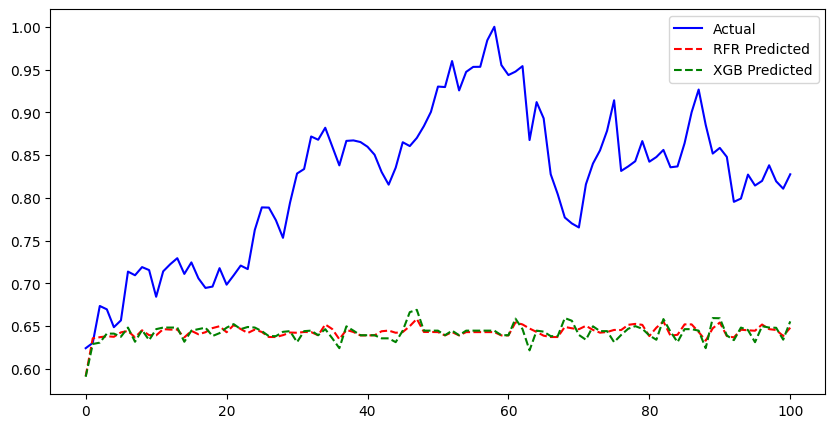

In [40]:
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)

rfr.fit(X_train, y_train)
xgb.fit(X_train, y_train)

y_pred_rfr = rfr.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

metrics = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_rfr),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    'MSE': [
        mean_squared_error(y_test, y_pred_rfr),
        mean_squared_error(y_test, y_pred_xgb)
    ],
    'R2': [
        r2_score(y_test, y_pred_rfr),
        r2_score(y_test, y_pred_xgb)
    ]
})

print(metrics)

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred_rfr, label='RFR Predicted', color='red', linestyle='--')
plt.plot(y_pred_xgb, label='XGB Predicted', color='green', linestyle='--')
plt.legend()
plt.show()

In [44]:

for r in  [len(y_test.values),
len(y_pred_rfr),
len(y_pred_xgb),
]:
    print(r)

101
101
101


In [45]:
new_df = pd.DataFrame({
    "rfr_pred" : y_pred_rfr,
    "xgb_pred": y_pred_xgb,
    "actual": y_test
})

print(new_df)

     rfr_pred  xgb_pred    actual
400  0.591667  0.590943  0.624341
401  0.635878  0.629252  0.630510
402  0.637193  0.630842  0.673696
403  0.638273  0.641387  0.669770
404  0.637703  0.641387  0.648906
..        ...       ...       ...
496  0.652019  0.650122  0.819854
497  0.646621  0.648472  0.838138
498  0.645635  0.648201  0.819405
499  0.638588  0.634313  0.810768
500  0.648322  0.655692  0.827594

[101 rows x 3 columns]


In [47]:
X = new_df.drop(columns=['actual'])
y = new_df['actual']

corr_target = X.corrwith(y).sort_values(ascending=False)
print("Correlation with target:\n", corr_target)

Correlation with target:
 rfr_pred    0.271270
xgb_pred    0.191973
dtype: float64


In [50]:
def add_actual_indicators(df: pd.DataFrame) -> pd.DataFrame:
    df['pct_change'] = df['actual'].pct_change() * 100  
    df['increase_ind'] = (df['actual'].diff() > 0).astype(int)
    df = df.dropna().reset_index(drop=True)

    return df

df = add_actual_indicators(new_df)
df.head()

,rfr_pred,xgb_pred,actual,pct_change,increase_ind
0,0.635878,0.629252,0.630510,0.988148,1
1,0.637193,0.630842,0.673696,6.849327,1
2,0.638273,0.641387,0.669770,-0.582761,0
3,0.637703,0.641387,0.648906,-3.115058,0
4,0.642830,0.637737,0.656870,1.227324,1


In [52]:
features = [col for col in df.columns if col not in ['actual']]
target = 'actual'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [53]:
model = XGBRegressor(
        n_estimators=300,      
        learning_rate=0.05,     
        max_depth=3,            
        subsample=0.8,          
        colsample_bytree=0.8,   
        reg_lambda=1.0,         
        reg_alpha=0.5,          
        random_state=42
    )

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

   mean_absolute_error  mean_squared_error  r2_score
0             0.033034            0.001636 -0.577272


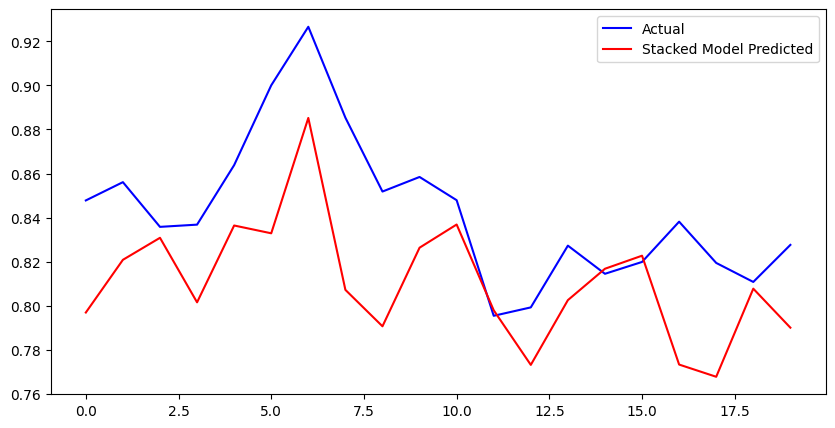

In [57]:
res_df = pd.DataFrame({
    "mean_absolute_error": [mean_absolute_error(y_test, y_pred)],
    "mean_squared_error": [mean_squared_error(y_test, y_pred)],
    "r2_score": [r2_score(y_test, y_pred)]
})

print(res_df)

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred, label='Stacked Model Predicted', color='red')
plt.legend()
plt.show()